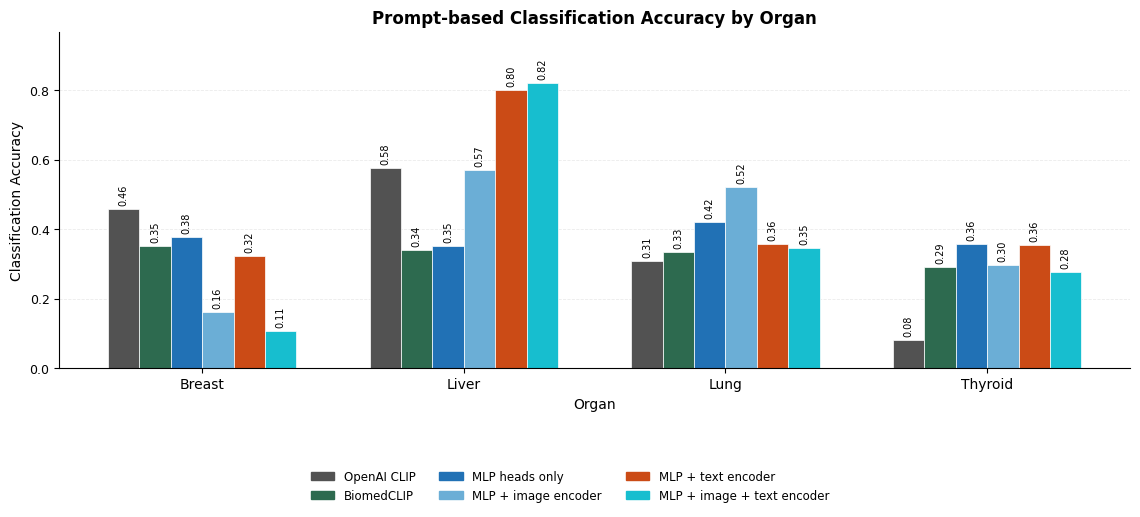

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

os.makedirs("figures_tables", exist_ok=True)

# =========================
# Load data
# =========================
csv_path = "per_organ_classification_results.csv"
df = pd.read_csv(csv_path)

# =========================
# Colors
# =========================
COLORS = {
    "OpenAI CLIP": "#525252",                 # dark gray
    "BiomedCLIP": "#2d6a4f",                  # dark green
    "MLP heads only": "#2171b5",              # blue
    "MLP + image encoder": "#6baed6",         # light blue
    "MLP + text encoder": "#cb4b16",          # orange
    "MLP + image + text encoder": "#17becf",  # teal
}

MODEL_ORDER = [
    "OpenAI CLIP",
    "BiomedCLIP",
    "MLP heads only",
    "MLP + image encoder",
    "MLP + text encoder",
    "MLP + image + text encoder",
]

ORGAN_LABELS = {
    "breast": "Breast",
    "liver": "Liver",
    "lung": "Lung",
    "thyroid": "Thyroid",
}

df = df[df["model"].isin(MODEL_ORDER)].copy()
df["organ_label"] = df["group_name"].map(lambda x: ORGAN_LABELS.get(str(x), str(x).title()))

# Keep organs in a stable order
organ_order = [o for o in ["breast", "liver", "lung", "thyroid"] if o in df["group_name"].unique()]
organ_labels = [ORGAN_LABELS.get(o, o.title()) for o in organ_order]

# =========================
# Plot
# =========================
fig, ax = plt.subplots(figsize=(11.5, 4.8))

x = np.arange(len(organ_order))
bar_width = 0.12
n_models = len(MODEL_ORDER)

for i, model in enumerate(MODEL_ORDER):
    sub = (
        df[df["model"] == model]
        .set_index("group_name")
        .reindex(organ_order)
    )

    heights = sub["accuracy"].to_numpy(dtype=float)
    xpos = x + (i - (n_models - 1) / 2) * bar_width

    ax.bar(
        xpos,
        heights,
        width=bar_width,
        color=COLORS[model],
        edgecolor="white",
        linewidth=0.5,
        label=model,
    )

# =========================
# Style
# =========================
ax.set_xticks(x)
ax.set_xticklabels(organ_labels, fontsize=10)
ax.set_ylabel("Classification Accuracy", fontsize=10)
ax.set_xlabel("Organ", fontsize=10)
ax.set_title("Prompt-based Classification Accuracy by Organ", fontsize=12, fontweight="bold")

ax.set_ylim(0, max(0.05, df["accuracy"].max() * 1.18))
ax.tick_params(axis="y", labelsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add light horizontal grid
ax.grid(axis="y", alpha=0.25, linestyle="--", linewidth=0.6)
ax.set_axisbelow(True)

# Add value labels
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if np.isnan(height):
            continue
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90,
        )

# Legend below
handles = [
    mpatches.Patch(color=COLORS[m], label=m)
    for m in MODEL_ORDER
    if m in df["model"].unique()
]

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=3,
    fontsize=8.5,
    frameon=False,
    bbox_to_anchor=(0.5, -0.08),
)

plt.tight_layout(rect=[0, 0.10, 1, 1])

plt.savefig("figures_tables/per_organ_accuracy_grouped.pdf", bbox_inches="tight", dpi=300)
plt.savefig("figures_tables/per_organ_accuracy_grouped.png", bbox_inches="tight", dpi=300)

plt.show()

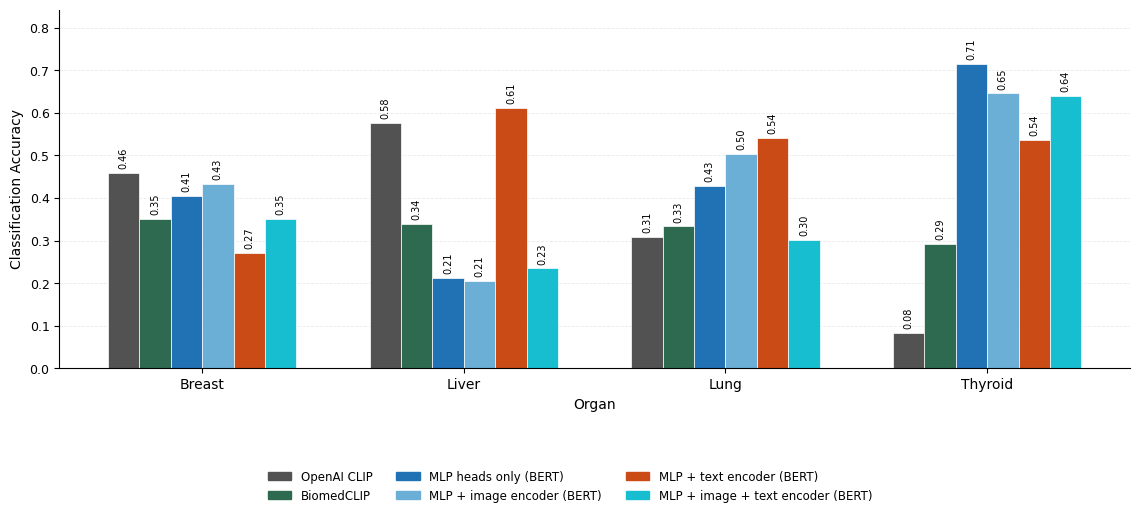

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

os.makedirs("figures_tables", exist_ok=True)

# =========================
# Load data
# =========================
csv_path = "per_organ_classification_results_BERT.csv"
df = pd.read_csv(csv_path)

# =========================
# Colors
# =========================
COLORS = {
    "OpenAI CLIP": "#525252",                 # dark gray
    "BiomedCLIP": "#2d6a4f",                  # dark green
    "MLP heads only (BERT)": "#2171b5",              # blue
    "MLP + image encoder (BERT)": "#6baed6",         # light blue
    "MLP + text encoder (BERT)": "#cb4b16",          # orange
    "MLP + image + text encoder (BERT)": "#17becf",  # teal
}

MODEL_ORDER = [
    "OpenAI CLIP",
    "BiomedCLIP",
    "MLP heads only (BERT)",
    "MLP + image encoder (BERT)",
    "MLP + text encoder (BERT)",
    "MLP + image + text encoder (BERT)",
]

ORGAN_LABELS = {
    "breast": "Breast",
    "liver": "Liver",
    "lung": "Lung",
    "thyroid": "Thyroid",
}

df = df[df["model"].isin(MODEL_ORDER)].copy()
df["organ_label"] = df["group_name"].map(lambda x: ORGAN_LABELS.get(str(x), str(x).title()))

# Keep organs in a stable order
organ_order = [o for o in ["breast", "liver", "lung", "thyroid"] if o in df["group_name"].unique()]
organ_labels = [ORGAN_LABELS.get(o, o.title()) for o in organ_order]

# =========================
# Plot
# =========================
fig, ax = plt.subplots(figsize=(11.5, 4.8))

x = np.arange(len(organ_order))
bar_width = 0.12
n_models = len(MODEL_ORDER)

for i, model in enumerate(MODEL_ORDER):
    sub = (
        df[df["model"] == model]
        .set_index("group_name")
        .reindex(organ_order)
    )

    heights = sub["accuracy"].to_numpy(dtype=float)
    xpos = x + (i - (n_models - 1) / 2) * bar_width

    ax.bar(
        xpos,
        heights,
        width=bar_width,
        color=COLORS[model],
        edgecolor="white",
        linewidth=0.5,
        label=model,
    )

# =========================
# Style
# =========================
ax.set_xticks(x)
ax.set_xticklabels(organ_labels, fontsize=10)
ax.set_ylabel("Classification Accuracy", fontsize=10)
ax.set_xlabel("Organ", fontsize=10)

ax.set_ylim(0, max(0.05, df["accuracy"].max() * 1.18))
ax.tick_params(axis="y", labelsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add light horizontal grid
ax.grid(axis="y", alpha=0.25, linestyle="--", linewidth=0.6)
ax.set_axisbelow(True)

# Add value labels
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if np.isnan(height):
            continue
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90,
        )

# Legend below
handles = [
    mpatches.Patch(color=COLORS[m], label=m)
    for m in MODEL_ORDER
    if m in df["model"].unique()
]

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=3,
    fontsize=8.5,
    frameon=False,
    bbox_to_anchor=(0.5, -0.08),
)

plt.tight_layout(rect=[0, 0.10, 1, 1])

plt.savefig("figures_tables/per_organ_accuracy_grouped.pdf", bbox_inches="tight", dpi=300)
plt.savefig("figures_tables/per_organ_accuracy_grouped.png", bbox_inches="tight", dpi=300)

plt.show()